# Introduction to Google Colab + Simple Linear Regression

In this notebook you will:
1. Create or verify a Google account.
2. Learn **how to open Google Colab from Gmail**.
3. Run your first cells and install libraries if needed.
4. Complete a **simple linear regression** task (predict apartment price from floor area).
5. Save results and **publish the project on GitHub**.


## 1) Google account — quick setup
- Go to [accounts.google.com/signup](https://accounts.google.com/signup).
- Fill in the form and **create a Google account** (or simply sign in if you already have one).
- After signing in, open **Gmail**: [mail.google.com](https://mail.google.com).

## 2) How to find **Google Colab** from Gmail
1. In Gmail, click the **Google apps menu** (9-dot icon in the top-right corner).
2. In the app grid, click **Colab**.
   > If Colab is missing: choose **“More from Google”** or open **https://colab.research.google.com** in the address bar.
3. In Colab choose: **File → Upload notebook** and upload `colab_regression.ipynb` from this project.

> Tip: alternatively use **File → Save a copy in Drive** and work on the copy in your Google Drive.


## 3) Colab basics
- **Markdown** cells (like this one) are for text and formatting.
- **Code** cells run Python.
- Run a cell with **Ctrl+Enter** (or **Shift+Enter** to run and move to the next cell).
- On the left you can open the **Files** panel and upload data (e.g. CSV).

Below we check the Python version and install libraries if needed.


In [1]:
import sys, platform
print("Python version:", sys.version)
print("Platform:", platform.platform())


Python version: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39


## 4) Install libraries (only if needed)
In Colab most libraries are already available. If something is missing, use `pip`:


In [2]:
# Uncomment if you need to install packages locally or in a custom environment:
# !pip install numpy pandas scikit-learn matplotlib


## 5) Data: `apartments.csv`
The project includes a sample file with **floor area (m²)** and **price (thousands of PLN)**.

Option A — load a local file (in Colab open **Files**, upload `apartments.csv`, then run the next cell):


In [5]:
import pandas as pd

# If you uploaded the file in Colab (Files panel on the left), this path should work:
df = pd.read_csv("apartments.csv")
df.head()


,area_m2,price_thousands_pln
0,35,310
1,42,355
2,50,395
3,57,430
4,65,470


**Option B — file on GitHub:** after publishing the repository, open `apartments.csv` on GitHub, click **Raw**, copy the URL, then:


In [6]:
# Example (replace with your own GitHub RAW URL):
# raw_url = "https://raw.githubusercontent.com/<your-user>/<your-repo>/main/apartments.csv"
# df = pd.read_csv(raw_url)
# df.head()


## 6) Simple linear regression
Goal: predict **price (thousands of PLN)** from **floor area (m²)**.
Steps:
1. Split features X (area) and target y (price).
2. Fit `LinearRegression`.
3. Inspect parameters (coefficient and intercept).
4. Plot the fitted line.


Coefficient (a): 5.435187608739161
Intercept (b): 122.55816101864565
Predicted price for 40 m²: 340.0 thousand PLN
Predicted price for 60 m²: 448.7 thousand PLN
Predicted price for 80 m²: 557.4 thousand PLN
Predicted price for 100 m²: 666.1 thousand PLN


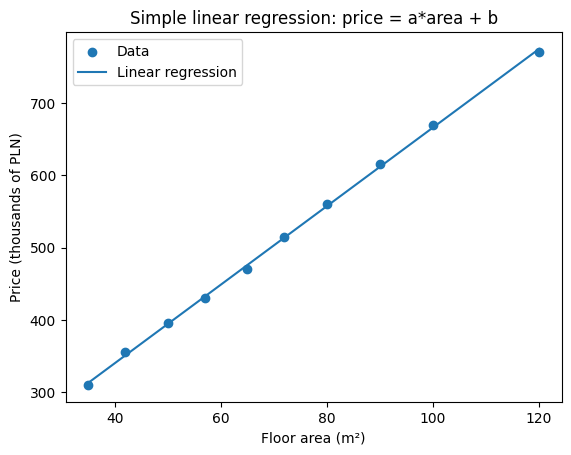

In [7]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# X: floor area (m²), y: price (thousands of PLN)
X = df[["area_m2"]].values
y = df["price_thousands_pln"].values

model = LinearRegression()
model.fit(X, y)

print("Coefficient (a):", model.coef_[0])
print("Intercept (b):", model.intercept_)

# Predictions for a few sample areas
sample = np.array([[40],[60],[80],[100]])
pred = model.predict(sample)
for m2, p in zip(sample.flatten(), pred):
    print(f"Predicted price for {m2} m²: {p:.1f} thousand PLN")

# Plot: points + regression line
plt.figure()
plt.scatter(X, y, label="Data")
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, label="Linear regression")
plt.xlabel("Floor area (m²)")
plt.ylabel("Price (thousands of PLN)")
plt.title("Simple linear regression: price = a*area + b")
plt.legend()
plt.show()


### Your exercises
1. Add a new column with **price per m²** (`price_per_m2`) and inspect how it changes across areas.
2. Add mild non-linearity (e.g. `area_m2^2` as an extra feature) and check whether the error decreases.
3. Save the plot as PNG (e.g. `plt.savefig("regression.png")`).

> Extension: split into **train/test** (`train_test_split`) and compute error metrics (e.g. MAE, RMSE).


## 7) Saving and sharing the notebook
- **File → Save a copy in GitHub** — choose repository and folder.
- **File → Download .ipynb** — download the notebook and upload it manually to GitHub.

## 8) Publish the whole project on GitHub (web UI)
1. Sign in at [github.com](https://github.com).
2. Click **New** and create a repository (e.g. `colab-regression`).
3. Drag and drop project files: `colab_regression.ipynb`, `apartments.csv`, `README.md`, `requirements.txt`, `.gitignore`.
4. Click **Commit changes**.
5. Open `colab_regression.ipynb` and check the preview. Optionally copy the **RAW URL** of `apartments.csv` for Option B above.

> Alternative (git in a terminal):
> ```bash
> git init
> git add .
> git commit -m "Initial commit: Colab + linear regression"
> git branch -M main
> git remote add origin https://github.com/<your-user>/<your-repo>.git
> git push -u origin main
> ```


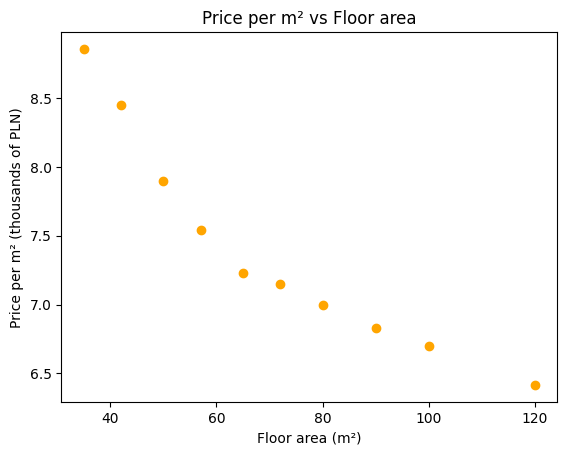

,area_m2,price_thousands_pln,price_per_m2
0,35,310,8.857143
1,42,355,8.452381
2,50,395,7.900000
3,57,430,7.543860
4,65,470,7.230769


In [8]:
# Exercise 1
df['price_per_m2'] = df['price_thousands_pln'] / df['area_m2']

plt.figure()
plt.scatter(df['area_m2'], df['price_per_m2'], color='orange')
plt.xlabel("Floor area (m²)")
plt.ylabel("Price per m² (thousands of PLN)")
plt.title("Price per m² vs Floor area")
plt.show()

df.head()

In [9]:
# Exercise 2
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Base Model MAE:", mean_absolute_error(y_test, y_pred))

df['area_m2_sq'] = df['area_m2'] ** 2
X_poly = df[['area_m2', 'area_m2_sq']].values

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)
poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train_p)
y_pred_p = poly_model.predict(X_test_p)

print("Polynomial Model MAE:", mean_absolute_error(y_test_p, y_pred_p))

Base Model MAE: 5.0546061345869475
Polynomial Model MAE: 5.613007490617235


Plot successfully saved as 'regression.png'!


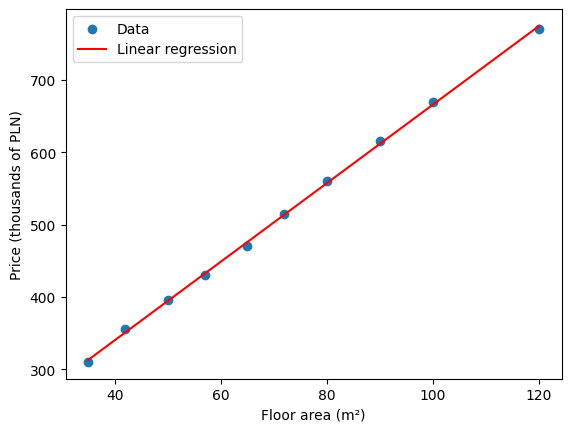

In [10]:
# Exercise 3
plt.figure()
plt.scatter(X, y, label="Data")
plt.plot(x_line, y_line, color='red', label="Linear regression")
plt.xlabel("Floor area (m²)")
plt.ylabel("Price (thousands of PLN)")
plt.legend()

plt.savefig("regression.png")
print("Plot successfully saved as 'regression.png'!")
plt.show()

---
Done! You can open **Colab from Gmail**, run code, complete a simple **linear regression**, and **publish the project on GitHub**.
Good luck!
